## compute and plot:

assembly loss
(assembly_f_unweighted vs assembly_f_weighted)

recovery by mapping
(assembly_f_weighted, assembly_f_readmapped_w)

reference comparison
(ref_f_weighted, assembly_refmap_isect_w)

irrecoverable content
(yaml_unknown_hashes / yaml_total_hashes)

biome-stratified analyses (after merging biome metadata)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/Users/ZYZhao/projects/AL/85/assembly/data/combined.table2.w_biome.csv")
df

,accession,assembly_f_unweighted,assembly_f_weighted,assembly_f_readmapped,assembly_f_readmapped_w,ref_f_unweighted,ref_f_weighted,f_reads_mapped,assembly_refmap_isect_w,yaml_n_bases,yaml_n_reads,yaml_kmers,yaml_known_hashes,yaml_unknown_hashes,yaml_total_hashes,biome1,biome2,biome3
0,DRR014782,0.276438,0.844373,0.423639,0.882288,0.536980,0.868853,0.905193,0.798369,8349341510,83531900,962104827,512950,442300,955250,Host-associated,Host-associated:Mammals,Host-associated:Mammals:Respiratory system
1,DRR014785,0.274877,0.831528,0.440818,0.876726,0.551175,0.863483,0.904628,0.783335,9188299904,91931356,1135708758,628307,511634,1139941,Host-associated,Host-associated:Mammals,Host-associated:Mammals:Respiratory system
2,DRR121397,0.137995,0.213100,0.265707,0.325096,0.110249,0.153467,0.371231,0.083111,1346724223,5715162,873225797,96682,780263,876945,Host-associated,Host-associated:Plants,Host-associated:Plants:Root
3,DRR121401,0.113473,0.164884,0.218902,0.261716,0.084405,0.107862,0.288395,0.051769,1106773348,4546672,804829188,68072,738422,806494,Host-associated,Host-associated:Plants,Host-associated:Plants:Root
4,ERR10695318,0.090915,0.921021,0.921988,0.995351,0.053441,0.748644,0.859269,0.746619,21495510640,143348680,938530613,49855,883041,932896,Engineered,Engineered:Food production,Engineered:Food production:Dairy products
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,SRR7610133,0.286185,0.606403,0.800946,0.880619,0.045155,0.289630,0.510271,0.283619,1688587848,5994846,735428843,32444,686054,718498,Host-associated,Host-associated:Fish,Host-associated:Fish:Digestive system
80,SRR9109404,0.225280,0.757587,0.580152,0.867478,0.125018,0.612335,0.646912,0.599182,5750423607,38762198,1129250325,141632,991258,1132890,Host-associated,Host-associated:Fish,Host-associated:Fish:Digestive system
81,SRR9182858,0.089677,0.355032,0.516287,0.664099,0.053390,0.234054,0.468480,0.200091,21502184416,145229898,10048069838,532215,9436149,9968364,Host-associated,Host-associated:Invertebrates,Host-associated:Invertebrates:Cnidaria
82,SRR9182859,0.101251,0.486127,0.604087,0.744169,0.074020,0.385528,0.644015,0.324084,24056532034,162463680,4334579990,321026,4015972,4336998,Host-associated,Host-associated:Invertebrates,Host-associated:Invertebrates:Cnidaria


## 1️⃣ Assembly loss (assembly_f_unweighted vs assembly_f_weighted)

- Unweighted: treat every k-mer equally, regardless of how often it appears.
- Unweighted: asks “how many different things survived?”

- Weighted: measures retention of k-mers weighted by their abundance in the reads.
- weighted: asks “how much of what we sequenced survived?”

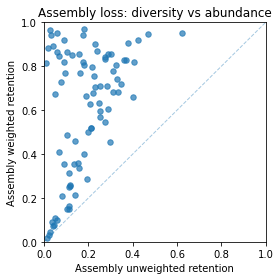

In [5]:
fig, ax = plt.subplots(figsize=(4, 4))

ax.scatter(
    df["assembly_f_unweighted"],
    df["assembly_f_weighted"],
    s=30,
    alpha=0.7
)

ax.plot([0, 1], [0, 1], "--", linewidth=1, alpha=0.4)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Assembly unweighted retention")
ax.set_ylabel("Assembly weighted retention")
ax.set_title("Assembly loss: diversity vs abundance")

plt.tight_layout()
plt.show()

## Figure X | Assembly loss is structured by abundance.
For each metagenome, unweighted k-mer retention is plotted against abundance-weighted retention for assembled contigs. Points lying above the diagonal indicate preferential retention of abundant k-mers. Across samples, assemblies retain a large fraction of abundance-weighted content while discarding most unique k-mers, demonstrating that assembly-associated content loss is systematic and structured by abundance.
- Points far above diagonal, assembly preserves what is abundant while discarding most of what is rare.

## 2️⃣ recovery by mapping (assembly_f_weighted, assembly_f_readmapped_w)

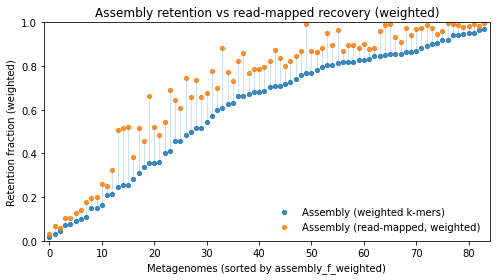

In [14]:
# keep needed cols
df = df.dropna(subset=["assembly_f_weighted", "assembly_f_readmapped_w"])

# sort by assembly weighted
df = df.sort_values("assembly_f_weighted").reset_index(drop=True)

x = np.arange(len(df))
y_asm = df["assembly_f_weighted"].to_numpy()
y_map = df["assembly_f_readmapped_w"].to_numpy()

fig, ax = plt.subplots(figsize=(7, 4))

# vertical connectors
ax.vlines(x, y_asm, y_map, linewidth=0.6, alpha=0.35)

# points
ax.scatter(x, y_asm, s=18, alpha=0.85, label="Assembly (weighted k-mers)")
ax.scatter(x, y_map, s=18, alpha=0.85, label="Assembly (read-mapped, weighted)")

# formatting
ax.set_xlim(-1, len(df))
ax.set_ylim(0, 1)
ax.set_xlabel("Metagenomes (sorted by assembly_f_weighted)")
ax.set_ylabel("Retention fraction (weighted)")
ax.set_title("Assembly retention vs read-mapped recovery (weighted)")

ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

## 3️⃣ Comparison w/ Ref-based (ref_f_weighted vs assembly_refmap_isect_w)

- How much reference-matched content overlaps with assembly
- Assembly vs reference representation of known sequence

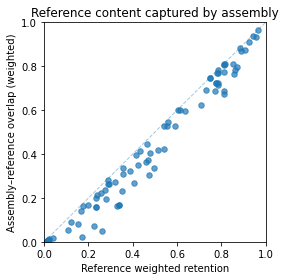

In [10]:
fig, ax = plt.subplots(figsize=(4, 4))

ax.scatter(
    df["ref_f_weighted"],
    df["assembly_refmap_isect_w"],
    s=30,
    alpha=0.7
)
ax.plot([0, 1], [0, 1], "--", linewidth=1, alpha=0.4)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Reference weighted retention")
ax.set_ylabel("Assembly–reference overlap (weighted)")
ax.set_title("Reference content captured by assembly")

plt.tight_layout()
plt.show()

## plot in three sections (on x-asix), representing three main biomes

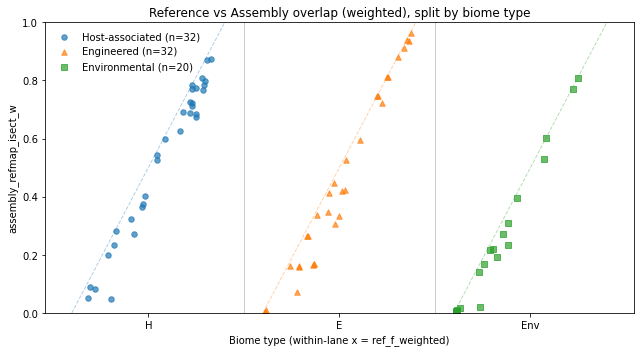

In [11]:
# map biome1 -> biome_type (3 groups)
def to_biome_type(b):
    if pd.isna(b):
        return "Environmental"
    b = str(b)
    if b.startswith("Host-associated"):
        return "Host-associated"
    if b.startswith("Engineered"):
        return "Engineered"
    return "Environmental"

df["biome_type"] = df["biome1"].apply(to_biome_type)

# keep needed rows
df = df.dropna(subset=["ref_f_weighted", "assembly_refmap_isect_w", "biome_type"])

order = ["Host-associated", "Engineered", "Environmental"]
lane_width = 1.2   # width allocated to each biome lane on x
gap = 0.3          # gap between lanes
lane_span = lane_width + gap

lane_start = {b: i * lane_span for i, b in enumerate(order)}
lane_center = {b: lane_start[b] + lane_width / 2 for b in order}

# build lane-x: scaled ref_f_weighted inside each lane
x_lane = []
for _, row in df.iterrows():
    b = row["biome_type"]
    x_lane.append(lane_start[b] + row["ref_f_weighted"] * lane_width)
df["x_lane"] = x_lane

# plot
fig, ax = plt.subplots(figsize=(9, 5))

# points (use different marker per biome to help)
markers = {"Host-associated": "o", "Engineered": "^", "Environmental": "s"}

for b in order:
    sub = df[df["biome_type"] == b]
    ax.scatter(
        sub["x_lane"],
        sub["assembly_refmap_isect_w"],
        s=30,
        alpha=0.7,
        marker=markers[b],
        label=f"{b} (n={len(sub)})"
    )

# y=x reference lines *within each lane* (optional but helpful)
for b in order:
    xs = np.array([0, 1])  # ref_f_weighted
    ax.plot(
        lane_start[b] + xs * lane_width,
        xs,  # y = x
        linestyle="--",
        linewidth=1,
        alpha=0.35
    )

# vertical separators between lanes
for i in range(1, len(order)):
    ax.axvline(i * lane_span - gap / 2, color="k", linewidth=1, alpha=0.2)

# x-axis ticks: biome labels at lane centers
ax.set_xticks([lane_center[b] for b in order])
ax.set_xticklabels(["H", "E", "Env"])
ax.set_xlabel("Biome type (within-lane x = ref_f_weighted)")
ax.set_ylabel("assembly_refmap_isect_w")
ax.set_title("Reference vs Assembly overlap (weighted), split by biome type")

ax.set_ylim(0, 1)
ax.legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.show()

Seems like no obvious biome type dependency

 ### plot corresponding assembly_f_weighted data, this reflected the percentage of unique content recovered by assembly, incontract with the intersection of assembly and refmap (assembly_refmap_isect_w)

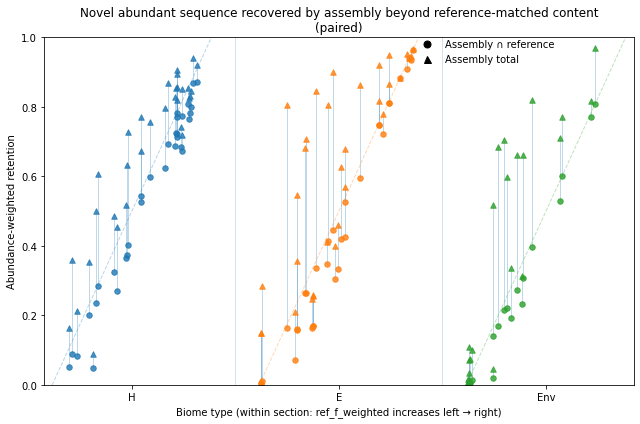

In [36]:
def biome_type(b):
    if pd.isna(b):
        return "Environmental"
    b = str(b)
    if b.startswith("Host-associated"):
        return "Host-associated"
    if b.startswith("Engineered"):
        return "Engineered"
    return "Environmental"

df["biome_type"] = df["biome1"].apply(biome_type)

df = df.dropna(subset=[
    "ref_f_weighted",
    "assembly_refmap_isect_w",
    "assembly_f_weighted",
    "biome_type"
])

# ----------------------------
# Lane geometry
# ----------------------------
order = ["Host-associated", "Engineered", "Environmental"]
lane_width = 1.0
gap = 0.3
lane_span = lane_width + gap

lane_start = {b: i * lane_span for i, b in enumerate(order)}
lane_center = {b: lane_start[b] + lane_width / 2 for b in order}

# x position within lane
df["x_lane"] = df.apply(
    lambda r: lane_start[r["biome_type"]] + r["ref_f_weighted"] * lane_width,
    axis=1
)

# ----------------------------
# Plot
# ----------------------------
colors = {
    "Host-associated": "#1f77b4",
    "Engineered": "#ff7f0e",
    "Environmental": "#2ca02c",
}

fig, ax = plt.subplots(figsize=(9, 6))

# vertical lollipops (novel abundant content)
ax.vlines(
    df["x_lane"],
    df["assembly_refmap_isect_w"],
    df["assembly_f_weighted"],
    linewidth=0.8,
    alpha=0.35,
    zorder=1
)

# points
for biome, color in colors.items():
    sub = df[df["biome_type"] == biome]
    ax.scatter(
        sub["x_lane"],
        sub["assembly_refmap_isect_w"],
        s=30,
        color=color,
        alpha=0.8,
        marker="o",
        label=f"{biome}: assembly ∩ ref",
        zorder=2
    )
    ax.scatter(
        sub["x_lane"],
        sub["assembly_f_weighted"],
        s=30,
        color=color,
        alpha=0.8,
        marker="^",
        label=f"{biome}: assembly total",
        zorder=3
    )

# within-lane y=x guide (optional)
for b in order:
    xs = np.array([0, 1])
    ax.plot(
        lane_start[b] + xs * lane_width,
        xs,
        linestyle="--",
        linewidth=1,
        alpha=0.3
    )

# vertical separators
for i in range(1, len(order)):
    ax.axvline(i * lane_span - gap / 2, linewidth=1, alpha=0.2)

# axis formatting
ax.set_xlim(-0.05, lane_start["Environmental"] + lane_width + 0.05)
ax.set_ylim(0, 1)

ax.set_xticks([lane_center[b] for b in order])
ax.set_xticklabels(["H", "E", "Env"])
ax.set_xlabel("Biome type (within section: ref_f_weighted increases left → right)")
ax.set_ylabel("Abundance-weighted retention")

ax.set_title(
    "Novel abundant sequence recovered by assembly beyond reference-matched content\n"
    "(paired)")

# clean legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
#ax.legend(by_label.values(), by_label.keys(), frameon=False, loc="lower right")

from matplotlib.lines import Line2D

legend_handles = [Line2D([0], [0],marker='o',color='k',linestyle='None',markersize=7,
label='Assembly ∩ reference'),
Line2D([0], [0],marker='^',color='k',linestyle='None',markersize=7,label='Assembly total'),]

ax.legend(handles=legend_handles,frameon=False,loc="upper center",bbox_to_anchor=(0.75, 1.02))

plt.tight_layout()
plt.show()

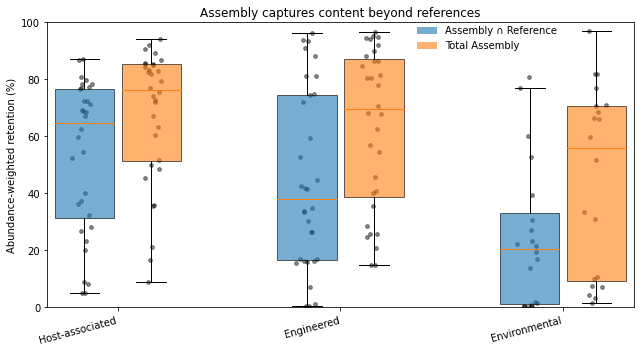

In [29]:
def biome_type(b):
    if pd.isna(b):
        return "Environmental"
    b = str(b)
    if b.startswith("Host-associated"):
        return "Host-associated"
    if b.startswith("Engineered"):
        return "Engineered"
    return "Environmental"

df["biome_type"] = df["biome1"].apply(biome_type)

# keep rows with both metrics
df = df.dropna(subset=["biome_type", "assembly_refmap_isect_w", "assembly_f_weighted"])

order = ["Host-associated", "Engineered", "Environmental"]  # match your example order if desired

# Prepare data lists for boxplot (left and right boxes per biome)
left_data = [df[df["biome_type"] == b]["assembly_refmap_isect_w"].to_numpy() for b in order]
right_data = [df[df["biome_type"] == b]["assembly_f_weighted"].to_numpy() for b in order]

# Positions: two boxes per biome
centers = np.arange(len(order)) * 3.0
offset = 0.45
pos_left = centers - offset
pos_right = centers + offset

fig, ax = plt.subplots(figsize=(9, 5))

# Boxplots
bp_left = ax.boxplot(
    left_data,
    positions=pos_left,
    widths=0.8,
    patch_artist=True,
    showfliers=False
)
bp_right = ax.boxplot(
    right_data,
    positions=pos_right,
    widths=0.8,
    patch_artist=True,
    showfliers=False
)

# Styling (no seaborn)
for patch in bp_left["boxes"]:
    patch.set_alpha(0.6)
for patch in bp_right["boxes"]:
    patch.set_alpha(0.6)

# give left/right different facecolors
for patch in bp_left["boxes"]:
    patch.set_facecolor("C0")  # left = assembly ∩ ref
for patch in bp_right["boxes"]:
    patch.set_facecolor("C1")  # right = total assembly

# Overlay jittered points (optional but informative)
rng = np.random.default_rng(0)
for i, b in enumerate(order):
    y1 = left_data[i]
    y2 = right_data[i]

    x1 = rng.normal(pos_left[i], 0.07, size=len(y1))
    x2 = rng.normal(pos_right[i], 0.07, size=len(y2))

    ax.scatter(x1, y1, s=14, alpha=0.45, color="k")
    ax.scatter(x2, y2, s=14, alpha=0.45, color="k")

# Axis formatting
ax.set_xticks(centers)
ax.set_xticklabels(order, rotation=15, ha="right")

ax.set_ylabel("Abundance-weighted retention (%)")
ax.set_ylim(0, 1)
ax.set_yticks(np.linspace(0, 1, 6))
ax.set_yticklabels([f"{int(v*100)}" for v in np.linspace(0, 1, 6)])

ax.set_title("Assembly captures content beyond references")

# Legend (manual)
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor="C0", alpha=0.6, label="Assembly ∩ Reference"),
    Patch(facecolor="C1", alpha=0.6, label="Total Assembly"),
]
ax.legend(handles=legend_handles, frameon=False, loc="upper center", bbox_to_anchor=(0.75, 1.02))

plt.tight_layout()
plt.show()

## analysis:
1) Assembly retains most abundant content across all biomes

- Orange boxes are consistently high across biomes
- Indicates that assembly preserves the dominant sequencing signal, even when references are incomplete

2) Reference coverage varies strongly by biome

- Host-associated:Blue and orange boxes are closer → references explain a larger fraction of abundant content

- Engineered: Moderate gap → partial reference representation

- Environmental: Largest gap → substantial abundant content absent from references

This directly reflects known differences in reference completeness across environments.

3) Assembly adds value beyond references

- Across all biomes: Orange > Blue. Assembly consistently recovers abundant, biologically real sequence that reference-based approaches miss

### Content loss during assembly is not equivalent to reference incompleteness.

## Irrecoverable content
(yaml_unknown_hashes / yaml_total_hashes)

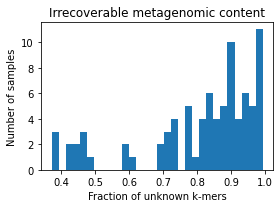

In [42]:
df["irrecoverable_fraction"] = (df["yaml_unknown_hashes"] / df["yaml_total_hashes"])

# A. Distribution across samples
fig, ax = plt.subplots(figsize=(4, 3))
ax.hist(df["irrecoverable_fraction"], bins=30)
ax.set_xlabel("Fraction of unknown k-mers")
ax.set_ylabel("Number of samples")
ax.set_title("Irrecoverable metagenomic content")

plt.tight_layout()
plt.show()

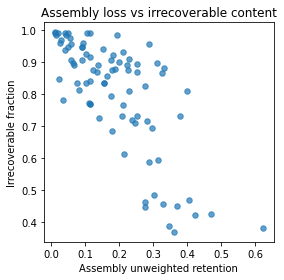

In [43]:
# B. Irrecoverable vs assembly loss
fig, ax = plt.subplots(figsize=(4, 4))

ax.scatter(df["assembly_f_unweighted"],df["irrecoverable_fraction"], s=30,alpha=0.7)
ax.set_xlabel("Assembly unweighted retention")
ax.set_ylabel("Irrecoverable fraction")
ax.set_title("Assembly loss vs irrecoverable content")

plt.tight_layout()
plt.show()

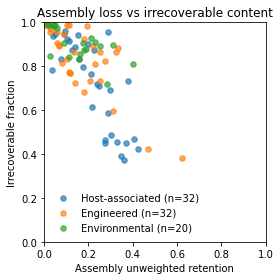

In [44]:
# color-code by biome type
df["biome_type"] = df["biome1"].apply(biome_type)

colors = {"Host-associated": "#1f77b4","Engineered": "#ff7f0e","Environmental": "#2ca02c",}
fig, ax = plt.subplots(figsize=(4, 4))

for biome, color in colors.items():
    sub = df[df["biome_type"] == biome]
    ax.scatter(sub["assembly_f_unweighted"],sub["irrecoverable_fraction"],s=30,alpha=0.7,
        color=color,label=f"{biome} (n={len(sub)})")

ax.set_xlabel("Assembly unweighted retention")
ax.set_ylabel("Irrecoverable fraction")
ax.set_title("Assembly loss vs irrecoverable content")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### Interperation:
Loss of unweighted (diversity-level) sequence content during metagenome assembly is strongly associated with irrecoverable sequence loss, particularly in environmental samples, indicating that a substantial fraction of rare and novel content cannot be recovered by either assembly or mapping.

- Environmental: Concentrated in the upper-left region, high irrecoverable fraction even when some assembly retention exists
- Environmental samples contain: high novelty, many low-abundance taxa, content absent from both assemblies and references

- Engineered: Clustered near moderate retention, Generally lower irrecoverable fraction than environmental samples
- Engineered systems tend to be: less diverse, better covered, more recoverable by mapping

- Host-associated: Broad spread, some samples retain diversity well (low irrecoverable fraction),others show substantial irrecoverable loss
- Likely reflects strain variation and uneven coverage within host environments